In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, roc_curve,
    confusion_matrix, matthews_corrcoef, make_scorer
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/elonmusk.csv')

In [ ]:
# Summary of data
print("Data Info:")
print(df.info())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12206 entries, 0 to 12205
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Tweet           12206 non-null  int64 
 1   UserScreenName  12206 non-null  object
 2   UserName        12206 non-null  object
 3   Timestamp       12206 non-null  object
 4   text            12206 non-null  object
 5   Emojis          854 non-null    object
 6   Comments        12186 non-null  object
 7   Likes           12183 non-null  object
 8   Retweets        12206 non-null  object
 9   Image link      12206 non-null  object
 10  Tweet URL       12206 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.0+ MB
None


In [ ]:
print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
              Tweet
count  12206.000000
mean    6102.500000
std     3523.713027
min        0.000000
25%     3051.250000
50%     6102.500000
75%     9153.750000
max    12205.000000


In [ ]:
print("\nFirst Rows:")
print(df.head())


First Rows:
   Tweet UserScreenName   UserName                 Timestamp  \
0      0      Elon Musk  @elonmusk  2010-06-04T18:31:57.000Z   
1      1      Elon Musk  @elonmusk  2011-12-01T09:55:11.000Z   
2      2      Elon Musk  @elonmusk  2011-12-01T10:29:04.000Z   
3      3      Elon Musk  @elonmusk  2011-12-03T08:20:28.000Z   
4      4      Elon Musk  @elonmusk  2011-12-03T08:22:07.000Z   

                                                text Emojis Comments Likes  \
0  Please ignore prior tweets, as that was someon...    NaN      873   648   
1  Went to Iceland on Sat to ride bumper cars on ...    NaN       30    24   
2  I made the volume on the Model S http://ow.ly/...    NaN       29    17   
3  Great Voltaire quote, arguably better than Twa...    NaN       23    30   
4      That was a total non sequitur btw\n26\n14\n50    NaN       26    14   

  Retweets                                         Image link  \
0    5,453                                                 []   
1  

In [ ]:
print("\nLast Rows:")
print(df.tail())


Last Rows:
       Tweet UserScreenName   UserName                 Timestamp  \
12201  12201      Elon Musk  @elonmusk  2022-03-03T04:25:03.000Z   
12202  12202      Elon Musk  @elonmusk  2022-03-03T08:13:32.000Z   
12203  12203      Elon Musk  @elonmusk  2022-03-02T03:15:03.000Z   
12204  12204      Elon Musk  @elonmusk  2022-03-04T21:40:29.000Z   
12205  12205      Elon Musk  @elonmusk  2022-03-04T19:17:16.000Z   

                                                    text Emojis Comments  \
12201      Replying to \n@TheBabylonBee\n515\n464\n14.5K      🤣      515   
12202  Replying to \n@OwenSparks_\n @ICannot_Enough\n...    NaN      286   
12203  Replying to \n@DBurkland\nInvestigating\n350\n...    NaN      350   
12204  Replying to \n@RenataKonkoly\n @MLUKBrandenbur...    NaN      233   
12205  Replying to \n@MLUKBrandenburg\n @gigafactory_...    NaN      620   

      Likes Retweets Image link  \
12201   464    14.5K         []   
12202   204    4,003         []   
12203   165    5,

In [ ]:
# Convert Likes, Retweets, and Comments to numeric values
numeric_cols = ['Likes', 'Retweets', 'Comments']
df[numeric_cols] = df[numeric_cols].replace(',', '', regex=True)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
# Identify numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

In [ ]:
# Fill missing values in numerical columns with median
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Confirm missing values are handled
print(df.isnull().sum())

Tweet                 0
UserScreenName        0
UserName              0
Timestamp             0
text                  0
Emojis            11352
Comments              0
Likes                 0
Retweets              0
Image link            0
Tweet URL             0
dtype: int64


Outlier **Detection**

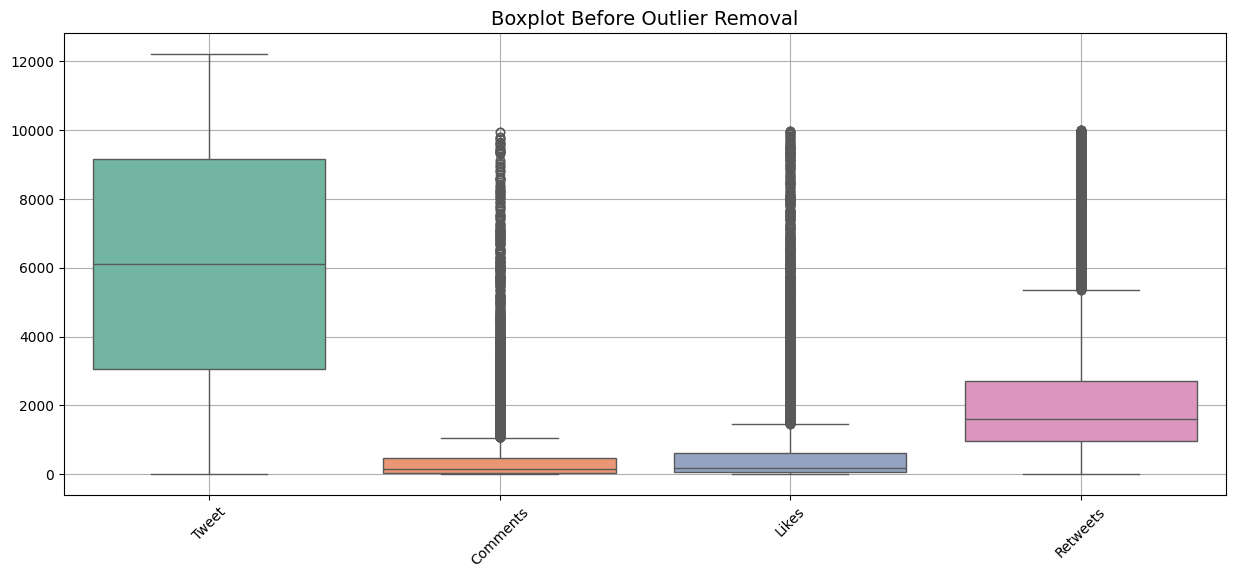

In [ ]:
# Boxplot before outlier removal
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, palette="Set2")
plt.title("Boxplot Before Outlier Removal", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Outlier removal using IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

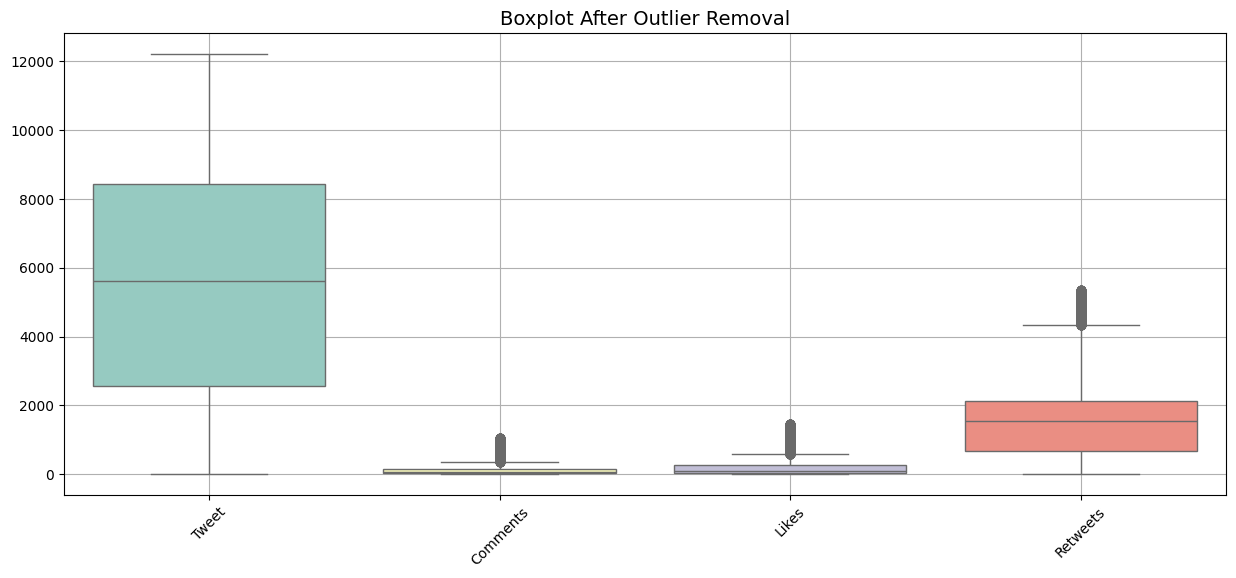

In [ ]:
# Boxplot after outlier removal
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_clean, palette="Set3")
plt.title("Boxplot After Outlier Removal", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Feature **Analysis**

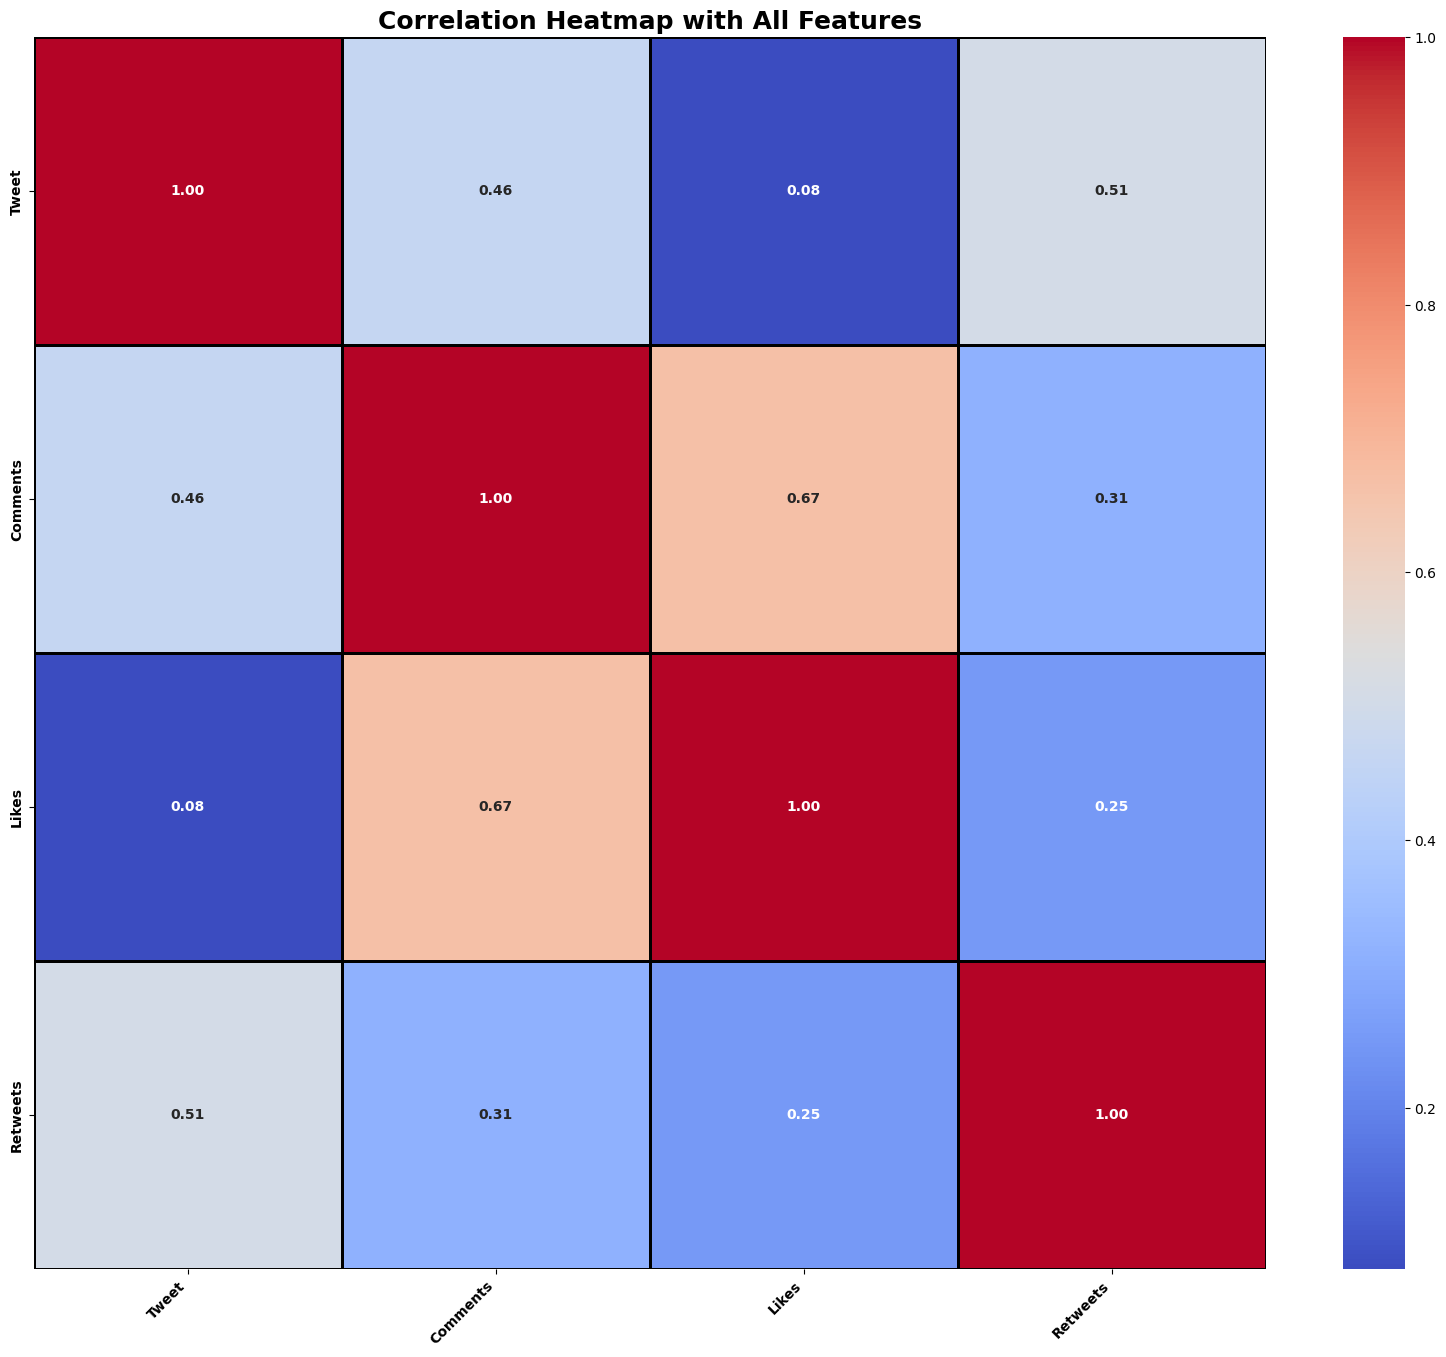

In [ ]:
plt.figure(figsize=(20, 16))
numeric_df_clean = df_clean.select_dtypes(include=np.number)
corr_matrix = numeric_df_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=1, linecolor='black', square=True, annot_kws={"size": 10, "fontweight": "bold"})
plt.xticks(fontsize=10, rotation=45, ha='right', fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.title("Correlation Heatmap with All Features", fontsize=18, fontweight='bold')
plt.show()


Pair Plot:


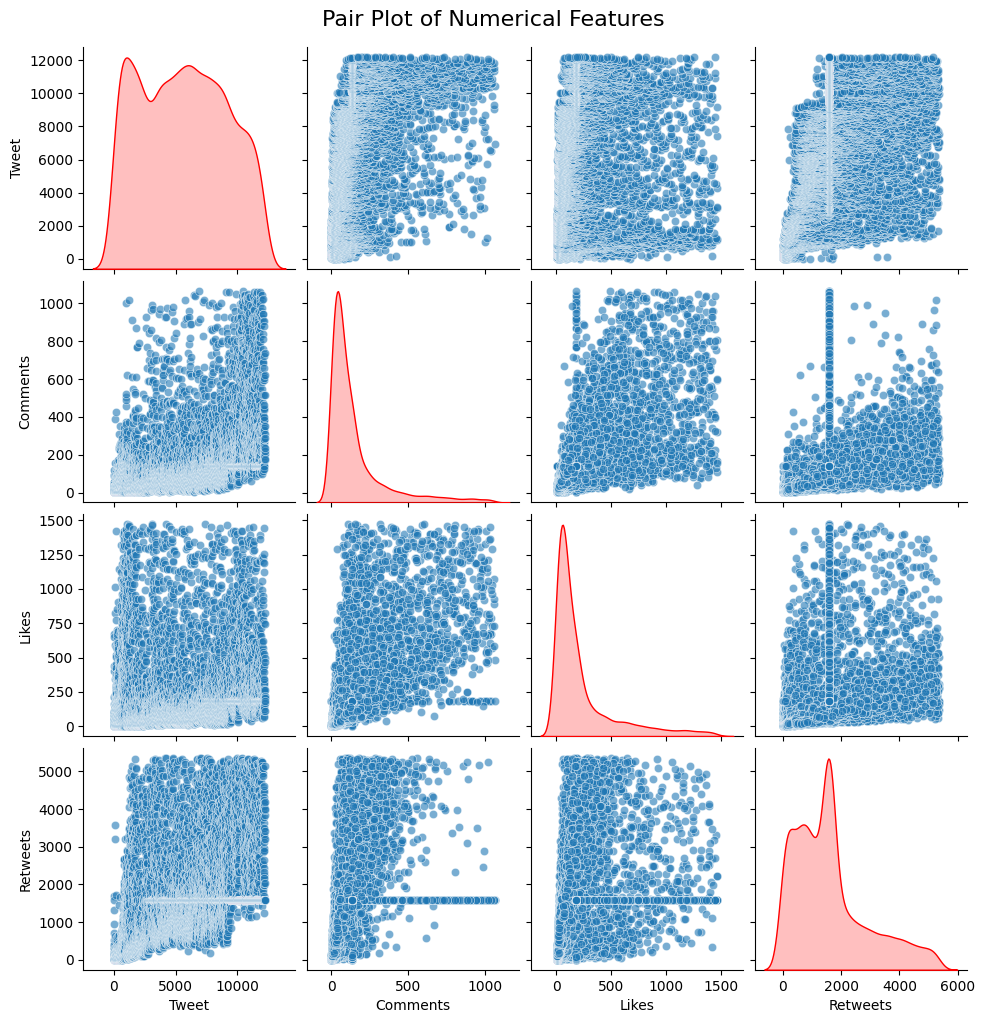

In [ ]:
print("\nPair Plot:")
sns.pairplot(df_clean[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.6}, diag_kws={'color': 'red'})
plt.suptitle("Pair Plot of Numerical Features", y=1.02, fontsize=16)
plt.show()

In [ ]:
# Encode categorical features
label_encoders = {}
for col in df_clean.select_dtypes(include=['object']).columns:
    if col != "target":
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        label_encoders[col] = le

**Normalization**

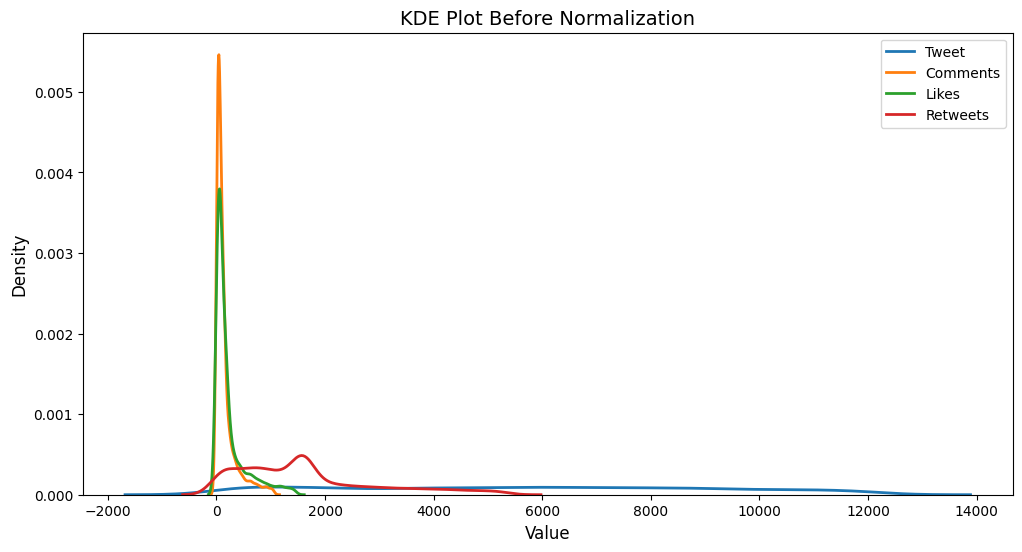

In [ ]:
plt.figure(figsize=(12, 6))
for col in numeric_cols:
    sns.kdeplot(df_clean[col], label=col, linewidth=2)
plt.title("KDE Plot Before Normalization", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
# 14. Perform normalization
scaler = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

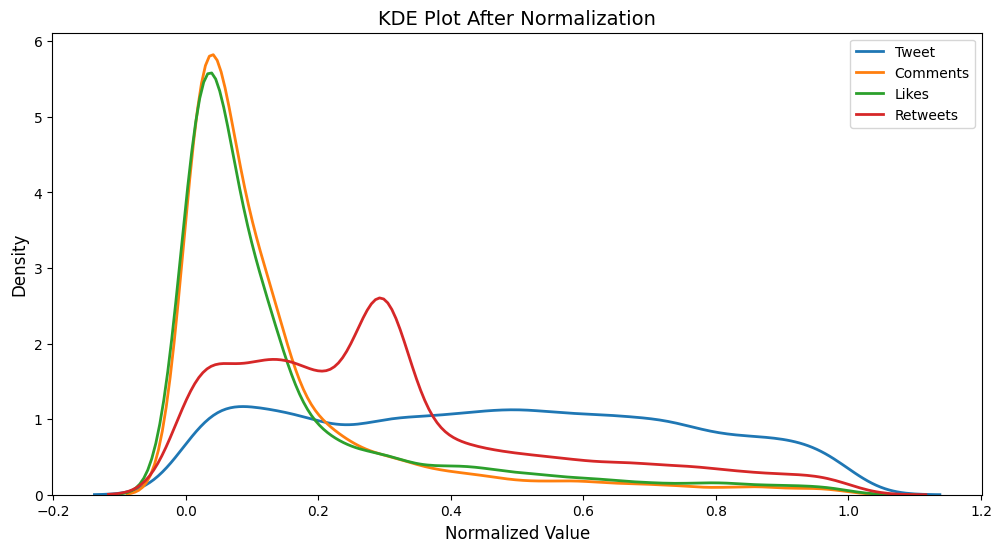

In [ ]:
# 15. Plot KDE graph after normalization
plt.figure(figsize=(12, 6))
for col in numeric_cols:
    sns.kdeplot(df_normalized[col], label=col, linewidth=2)
plt.title("KDE Plot After Normalization", fontsize=14)
plt.xlabel("Normalized Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
# We'll consider tweets with Likes > median as high engagement (1) and others as low (0)
median_likes = df_normalized['Likes'].median()
df_normalized['High_Engagement'] = (df_normalized['Likes'] > median_likes).astype(int)


In [ ]:
# Prepare features and target
X = df_normalized[numeric_cols].drop('Likes', axis=1)
y = df_normalized['High_Engagement']

SMOTE(CLASS DISTRIBUTION)

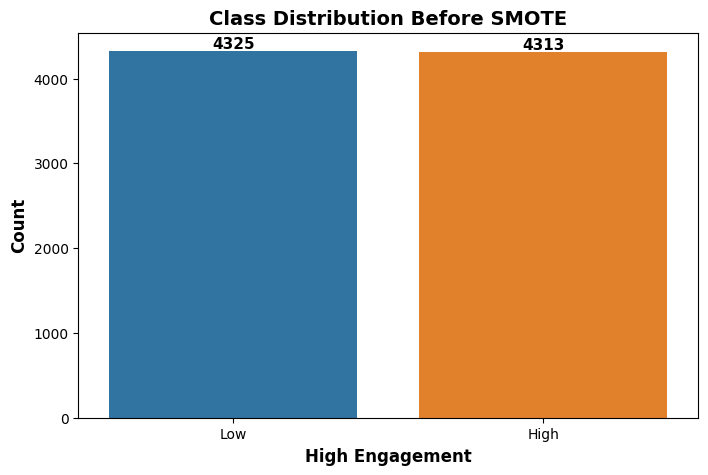

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y, palette=['#1f77b4', '#ff7f0e'])

# Add labels directly
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.title("Class Distribution Before SMOTE", fontsize=14, fontweight="bold")
plt.xlabel("High Engagement", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.xticks([0, 1], ['Low', 'High'])
plt.grid(False)
plt.show()

In [ ]:
# Split data before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [ ]:
# 17. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

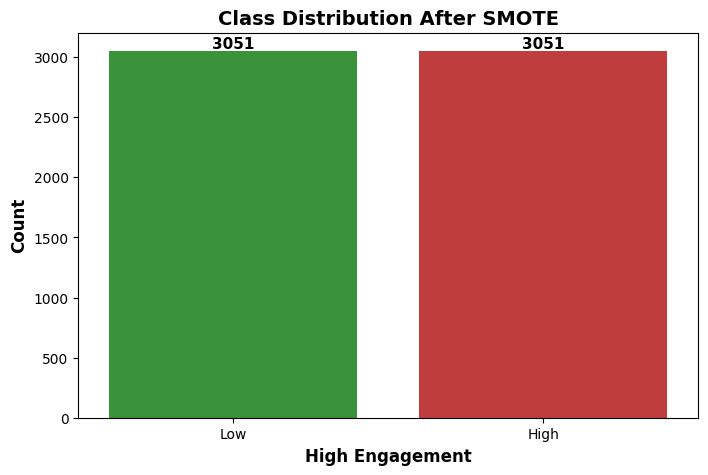

In [ ]:
# Plot class distribution after SMOTE
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y_train_smote, palette=['#2ca02c', '#d62728'])

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.title("Class Distribution After SMOTE", fontsize=14, fontweight="bold")
plt.xlabel("High Engagement", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.xticks([0, 1], ['Low', 'High'])
plt.grid(False)
plt.show()

**MODELS**

In [ ]:

def plot_roc_curve(y_test, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})', color='darkorange')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    return roc_auc


In [ ]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:

def calculate_specificity(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

1st model(MLP CLASSIFIER)

In [ ]:
# Training
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_smote, y_train_smote)


MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

In [ ]:
# Prediction
mlp_pred = mlp.predict(X_test)
mlp_prob = mlp.predict_proba(X_test)[:, 1]

# Accuracy
mlp_train_acc = mlp.score(X_train_smote, y_train_smote)
mlp_test_acc = mlp.score(X_test, y_test)



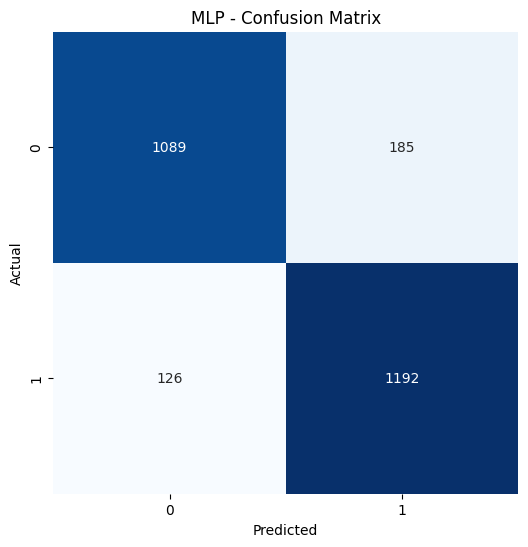

In [ ]:
# Classification Report
mlp_report = classification_report(y_test, mlp_pred)

# Confusion Matrix
mlp_cm = confusion_matrix(y_test, mlp_pred)
plot_confusion_matrix(mlp_cm, "MLP")

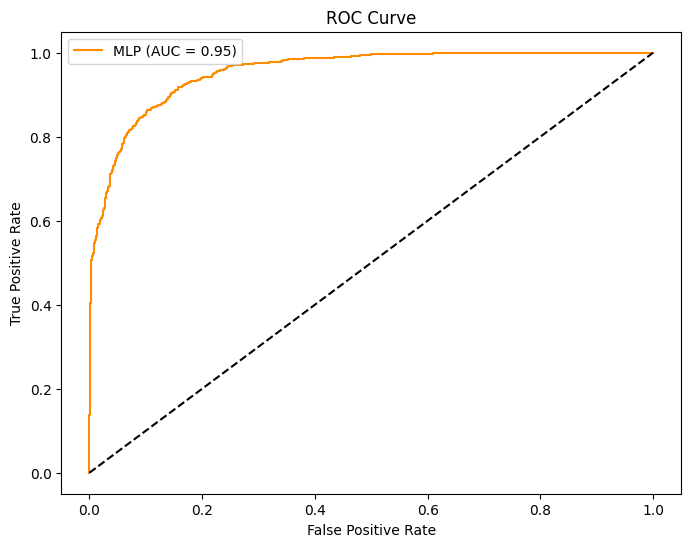

In [ ]:
# ROC AUC
mlp_auc = plot_roc_curve(y_test, mlp_prob, "MLP")


In [ ]:

# Specificity
mlp_specificity = calculate_specificity(mlp_cm)

# MCC
mlp_mcc = matthews_corrcoef(y_test, mlp_pred)

# Cross-validation
mlp_cv = cross_val_score(mlp, X_train_smote, y_train_smote, cv=10, scoring='accuracy')



In [ ]:

# Results
print("🔹 MLP Results 🔹")
print(f"Train Accuracy: {mlp_train_acc:.4f}")
print(f"Test Accuracy: {mlp_test_acc:.4f}")
print(f"ROC AUC: {mlp_auc:.4f}")
print(f"Specificity: {mlp_specificity:.4f}")
print(f"MCC: {mlp_mcc:.4f}")
print("Classification Report:\n", mlp_report)
print("Cross-Validation Scores:", mlp_cv)
print(f"Mean CV Accuracy: {mlp_cv.mean():.4f}")

🔹 MLP Results 🔹
Train Accuracy: 0.8763
Test Accuracy: 0.8800
ROC AUC: 0.9549
Specificity: 0.8548
MCC: 0.7606
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88      1274
           1       0.87      0.90      0.88      1318

    accuracy                           0.88      2592
   macro avg       0.88      0.88      0.88      2592
weighted avg       0.88      0.88      0.88      2592

Cross-Validation Scores: [0.87888707 0.87561375 0.87213115 0.86557377 0.87377049 0.87377049
 0.87540984 0.87377049 0.87213115 0.87540984]
Mean CV Accuracy: 0.8736


2ND(Extra Trees Classifier)

In [ ]:
#training
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)
etc.fit(X_train_smote, y_train_smote)

ExtraTreesClassifier(random_state=42)

In [ ]:
#prediction
etc_pred = etc.predict(X_test)
etc_prob = etc.predict_proba(X_test)[:, 1]

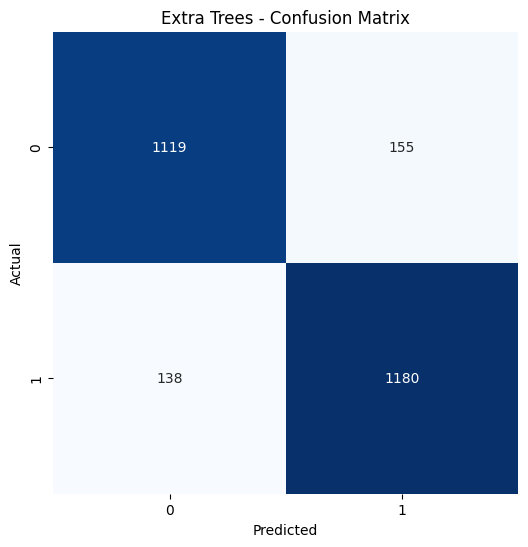

In [ ]:
#accuracy
etc_train_acc = etc.score(X_train_smote, y_train_smote)
etc_test_acc = etc.score(X_test, y_test)

#classifier report
etc_report = classification_report(y_test, etc_pred)

#confusion matrix
etc_cm = confusion_matrix(y_test, etc_pred)
plot_confusion_matrix(etc_cm, "Extra Trees")

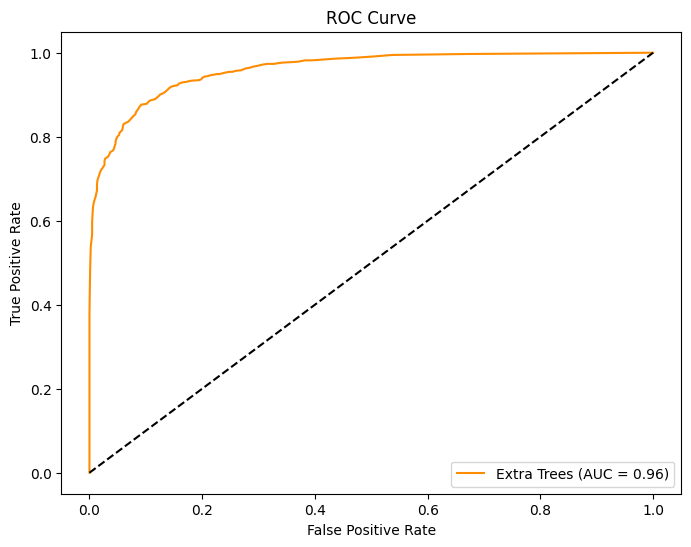

In [ ]:
#ROC AUC
etc_auc = plot_roc_curve(y_test, etc_prob, "Extra Trees")

#specificity
etc_specificity = calculate_specificity(etc_cm)

#MCC
etc_mcc = matthews_corrcoef(y_test, etc_pred)

#Cross-Validation
etc_cv = cross_val_score(etc, X_train_smote, y_train_smote, cv=10, scoring='accuracy')


In [ ]:
#Results
print("🔹 Extra Trees Results 🔹")
print(f"Train Accuracy: {etc_train_acc:.4f}")
print(f"Test Accuracy: {etc_test_acc:.4f}")
print(f"ROC AUC: {etc_auc:.4f}")
print(f"Specificity: {etc_specificity:.4f}")
print(f"MCC: {etc_mcc:.4f}")
print("Classification Report:\n", etc_report)
print("Cross-Validation Scores:", etc_cv)
print(f"Mean CV Accuracy: {etc_cv.mean():.4f}")


🔹 Extra Trees Results 🔹
Train Accuracy: 1.0000
Test Accuracy: 0.8870
ROC AUC: 0.9597
Specificity: 0.8783
MCC: 0.7739
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88      1274
           1       0.88      0.90      0.89      1318

    accuracy                           0.89      2592
   macro avg       0.89      0.89      0.89      2592
weighted avg       0.89      0.89      0.89      2592

Cross-Validation Scores: [0.86743044 0.8903437  0.85901639 0.87213115 0.88032787 0.87704918
 0.87868852 0.88196721 0.87213115 0.89016393]
Mean CV Accuracy: 0.8769


3RD(XGBoost Classifier)

In [ ]:
#training
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
try:
    from xgboost import XGBClassifier

    xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb.fit(X_train_smote, y_train_smote)
except ImportError:
    print("XGBoost is not installed. Please install it using 'pip install xgboost'")


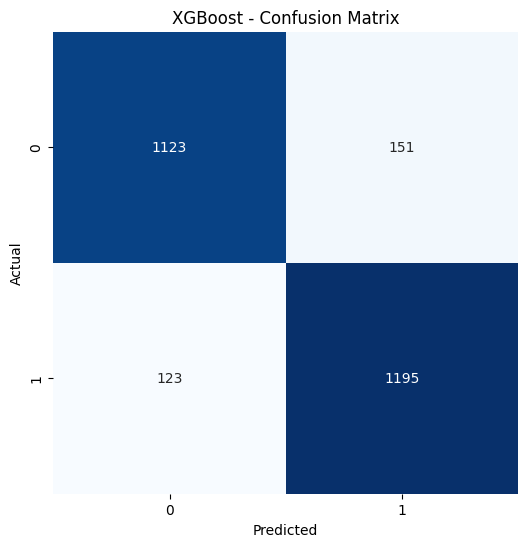

In [ ]:
#prediction
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
#accuracy
xgb_train_acc = xgb.score(X_train_smote, y_train_smote)
xgb_test_acc = xgb.score(X_test, y_test)

#classifier report
xgb_report = classification_report(y_test, xgb_pred)

#confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
plot_confusion_matrix(xgb_cm, "XGBoost")

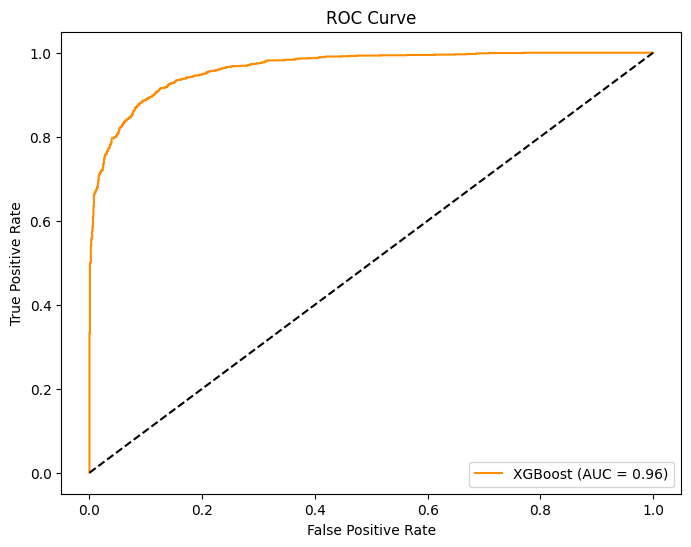

In [ ]:
#ROC AUC
xgb_auc = plot_roc_curve(y_test, xgb_prob, "XGBoost")

#specificity
xgb_specificity = calculate_specificity(xgb_cm)

#MCC
xgb_mcc = matthews_corrcoef(y_test, xgb_pred)

#Cross-Validation
xgb_cv = cross_val_score(xgb, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

In [ ]:
#results
print("🔹 XGBoost Results 🔹")
print(f"Train Accuracy: {xgb_train_acc:.4f}")
print(f"Test Accuracy: {xgb_test_acc:.4f}")
print(f"ROC AUC: {xgb_auc:.4f}")
print(f"Specificity: {xgb_specificity:.4f}")
print(f"MCC: {xgb_mcc:.4f}")
print("Classification Report:\n", xgb_report)
print("Cross-Validation Scores:", xgb_cv)
print(f"Mean CV Accuracy: {xgb_cv.mean():.4f}")

🔹 XGBoost Results 🔹
Train Accuracy: 0.9567
Test Accuracy: 0.8943
ROC AUC: 0.9637
Specificity: 0.8815
MCC: 0.7886
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      1274
           1       0.89      0.91      0.90      1318

    accuracy                           0.89      2592
   macro avg       0.89      0.89      0.89      2592
weighted avg       0.89      0.89      0.89      2592

Cross-Validation Scores: [0.87070376 0.89198036 0.86721311 0.87540984 0.87377049 0.88032787
 0.88688525 0.88688525 0.88688525 0.9       ]
Mean CV Accuracy: 0.8820


4TH(RANDOM FOREST)

In [ ]:
# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:

# Prediction
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:

# Accuracy
rf_train_acc = rf_model.score(X_train_smote, y_train_smote)
rf_test_acc = rf_model.score(X_test, y_test)

# Classification Report
rf_report = classification_report(y_test, rf_pred)

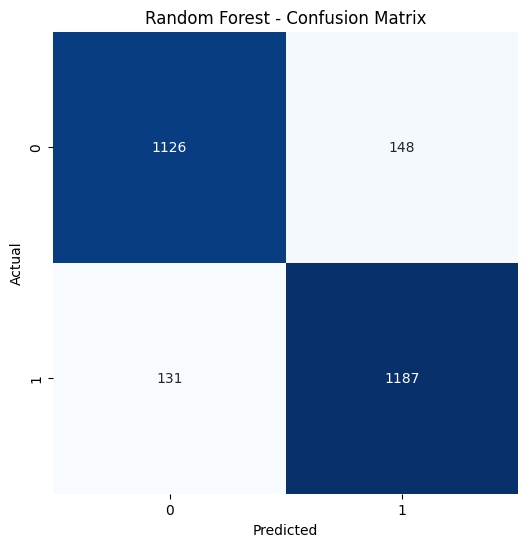

In [ ]:

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
plot_confusion_matrix(rf_cm, "Random Forest")


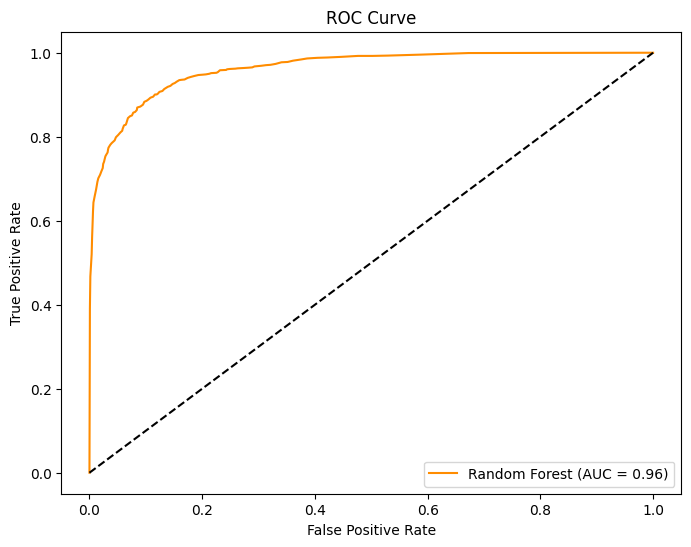

In [ ]:
# ROC AUC
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = plot_roc_curve(y_test, rf_prob, "Random Forest")

In [ ]:
# Specificity
rf_specificity = calculate_specificity(rf_cm)

# MCC
rf_mcc = matthews_corrcoef(y_test, rf_pred)

# Cross-Validation
rf_cv = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

In [ ]:

# Results
print("🔹 Random Forest Results 🔹")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")
print(f"ROC AUC: {rf_auc:.4f}")
print(f"Specificity: {rf_specificity:.4f}")
print(f"MCC: {rf_mcc:.4f}")
print("Classification Report:\n", rf_report)
print("Cross-Validation Scores:", rf_cv)
print(f"Mean CV Accuracy: {rf_cv.mean():.4f}")

🔹 Random Forest Results 🔹
Train Accuracy: 0.9993
Test Accuracy: 0.8924
ROC AUC: 0.9620
Specificity: 0.8838
MCC: 0.7847
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      1274
           1       0.89      0.90      0.89      1318

    accuracy                           0.89      2592
   macro avg       0.89      0.89      0.89      2592
weighted avg       0.89      0.89      0.89      2592

Cross-Validation Scores: [0.86579378 0.88870704 0.86393443 0.86557377 0.87704918 0.86885246
 0.88032787 0.8852459  0.87377049 0.89672131]
Mean CV Accuracy: 0.8766


**LIME_GRAPH**

In [ ]:
!pip install lime

import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
# Create a SHAP explainer, replace model with your desired model (e.g., rf_model)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1ab98bbac1c0b7171f2ed0769b1806dace271ea5004a7c76ef55ff13cdefe9e8
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
# Create a SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

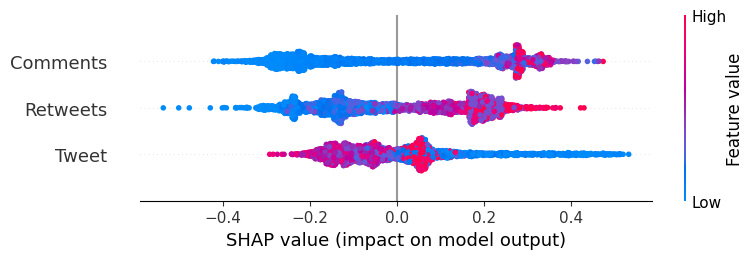

In [ ]:
# SHAP Summary Plot
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)

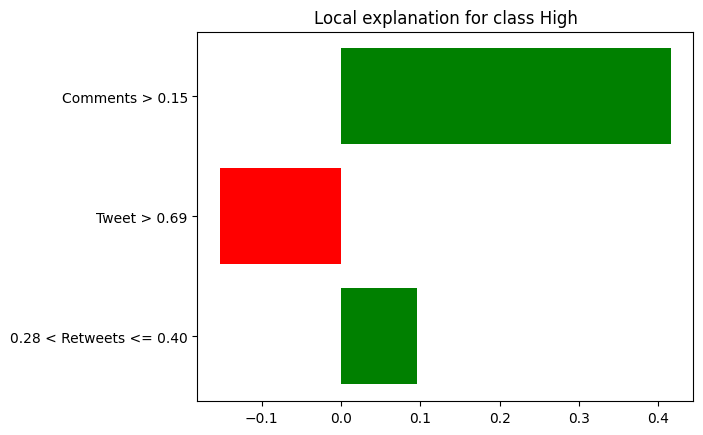

In [ ]:
# Create Lime Explainer
lime_explainer = LimeTabularExplainer(
    X_train.values,
    training_labels=y_train,
    mode='classification',
    feature_names=X_train.columns.tolist(),
    class_names=['Low', 'High'],
    discretize_continuous=True
)

# Select a data point to explain
index = 10
lime_explanation = lime_explainer.explain_instance(X_test.iloc[index].values, rf_model.predict_proba) # Use iloc to access row by index

# LIME Explanation Visualization
lime_explanation.as_pyplot_figure()
plt.show()